In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

import joblib

In [4]:
df = pd.read_csv("../data/raw/churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [6]:
X = df.drop(["customerID", "Churn"], axis=1)

y = df["Churn"]

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (5634, 19)
Testing: (1409, 19)


In [8]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numeric: 4
Categorical: 15


In [9]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [10]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [12]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [13]:
log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [14]:
y_prob_log = log_model.predict_proba(X_test)[:, 1]

y_pred_log = (y_prob_log >= 0.5).astype(int)

In [15]:
roc_auc_log = roc_auc_score(y_test, y_prob_log)

pr_auc_log = average_precision_score(y_test, y_prob_log)

f1_log = f1_score(y_test, y_pred_log)

recall_log = recall_score(y_test, y_pred_log)

print("Logistic Regression")
print("ROC-AUC:", roc_auc_log)
print("PR-AUC:", pr_auc_log)
print("F1:", f1_log)
print("Recall:", recall_log)

Logistic Regression
ROC-AUC: 0.8418739827946988
PR-AUC: 0.6333875698448933
F1: 0.6040462427745664
Recall: 0.5588235294117647


In [16]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [17]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [18]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

y_pred_rf = (y_prob_rf >= 0.5).astype(int)

In [19]:
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

pr_auc_rf = average_precision_score(y_test, y_prob_rf)

f1_rf = f1_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

print("Random Forest")
print("ROC-AUC:", roc_auc_rf)
print("PR-AUC:", pr_auc_rf)
print("F1:", f1_rf)
print("Recall:", recall_rf)

Random Forest
ROC-AUC: 0.8163657030664703
PR-AUC: 0.6058430084955272
F1: 0.534711964549483
Recall: 0.4839572192513369


In [20]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [roc_auc_log, roc_auc_rf],
    "PR-AUC": [pr_auc_log, pr_auc_rf],
    "F1": [f1_log, f1_rf],
    "Recall": [recall_log, recall_rf]
})

results

,Model,ROC-AUC,PR-AUC,F1,Recall
0,Logistic Regression,0.841874,0.633388,0.604046,0.558824
1,Random Forest,0.816366,0.605843,0.534712,0.483957


In [21]:
print("Notebook is working")

Notebook is working


In [22]:
print("Notebook is working")

Notebook is working


In [23]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [roc_auc_log, roc_auc_rf],
    "PR-AUC": [pr_auc_log, pr_auc_rf],
    "F1": [f1_log, f1_rf],
    "Recall": [recall_log, recall_rf]
})

results

,Model,ROC-AUC,PR-AUC,F1,Recall
0,Logistic Regression,0.841874,0.633388,0.604046,0.558824
1,Random Forest,0.816366,0.605843,0.534712,0.483957


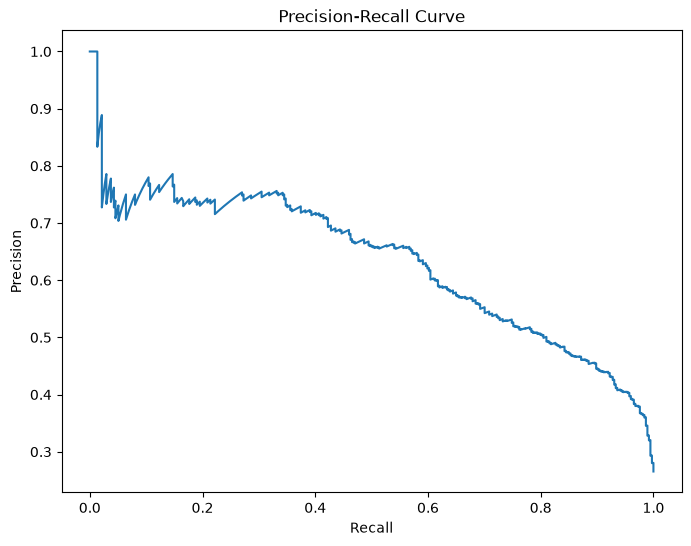

In [24]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_log
)

plt.figure(figsize=(8,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.savefig(
    "../reports/figures/pr_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


In [25]:
chosen_threshold = 0.35

y_pred_threshold = (
    y_prob_log >= chosen_threshold
).astype(int)

print("Threshold:", chosen_threshold)

print("Precision:",
      precision_score(y_test, y_pred_threshold))

print("Recall:",
      recall_score(y_test, y_pred_threshold))

print("F1:",
      f1_score(y_test, y_pred_threshold))

Threshold: 0.35
Precision: 0.5443298969072164
Recall: 0.7058823529411765
F1: 0.6146682188591386


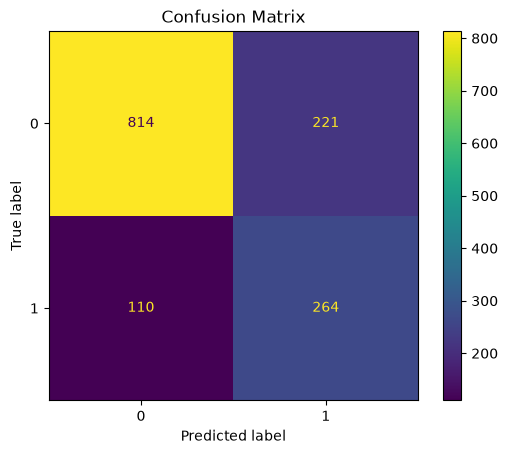

In [26]:
cm = confusion_matrix(
    y_test,
    y_pred_threshold
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.savefig(
    "../reports/figures/confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [27]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(10)

importance_df

,Feature,Importance
3,num__TotalCharges,0.162669
1,num__tenure,0.137204
2,num__MonthlyCharges,0.136437
36,cat__Contract_Month-to-month,0.047818
18,cat__OnlineSecurity_No,0.033157
43,cat__PaymentMethod_Electronic check,0.032611
16,cat__InternetService_Fiber optic,0.029921
27,cat__TechSupport_No,0.024712
0,num__SeniorCitizen,0.019705
21,cat__OnlineBackup_No,0.018314


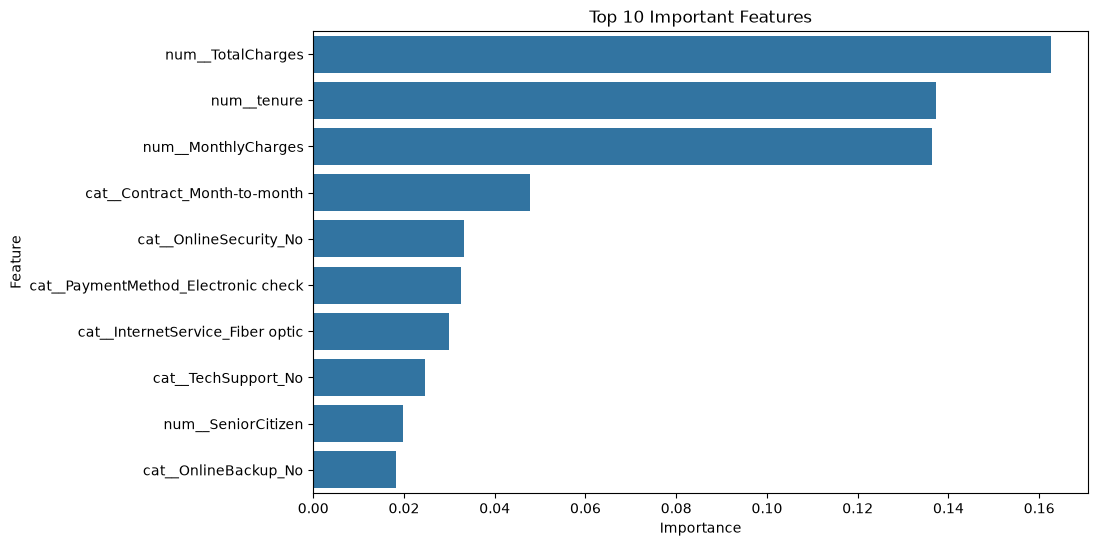

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.savefig(
    "../reports/figures/top_features.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [29]:
joblib.dump(
    rf_model,
    "../models/model.joblib"
)

print("Model saved!")

Model saved!
